In [1]:
def getDist(cord1,cord2):
    return (
        (float(cord1[0])-float(cord2[0]))**2+
        (float(cord1[1])-float(cord2[1]))**2+
        (float(cord1[2])-float(cord2[2]))**2)**0.5 * 10

class gro:    # ndx = {chineID : (start atomNdx, end atomNdx)}
    def __init__(self, groFile, proAtomNdx, ligAtomNdx):
        from tqdm import tqdm
        self.version = "groObj V.2"
        self.type = "Multi Chains"
        with open(groFile, "r") as gro:
            groLines = gro.readlines()
            self.atomNum = groLines[1]
        self.frames = {} # { frameNdx : { atomNdx : { resNdx : x, coord : (x, y, x) } } }
        frameNdx = 0
        atomDic = {}
        resNdx = groLines[2].split()[:-3]
        for line in tqdm(groLines[2:]):
            line_list = line.split()
            if len(line_list) == 3:
                self.frames[frameNdx] = atomDic
                # self.getResData(frameNdx)
                frameNdx = frameNdx + 1
                atomDic = {}
            elif "Title" not in line and len(line.split()) > 3:
                #print(line)
                atomNdx = int(line.split()[2])
                atomDic[atomNdx] = {
                    "resNdx" : int(line.split()[0][:-3]),
                    "coord" : (
                        float(line.split()[3]),
                        float(line.split()[4]),
                        float(line.split()[5])
                    )
                }
        print("> getting resData")
        resData = {
            "proRes": self.getRes(ndx=proAtomNdx),
            "ligRes": self.getRes(ndx=ligAtomNdx)
            }
        import pickle
        print("> saving resData")
        with open("resData.pkl", "wb") as resDataF:
            pickle.dump(resData, resDataF)
    def getRes(self, ndx):
        frameDic = {} # { frameNdx : { resNdx : { atomNdx : (coord) } } }
        for frame in self.frames.items():# { frameNdx : { atomNdx : { resNdx : x, coord : (x, y, x) } } }
            frameNdx = frame[0]
            atomDic = frame[1]
            resDic = {}
            for atomNdx in range(ndx[0], ndx[1]+1):
                resNdx = atomDic[atomNdx]["resNdx"]
                coord = atomDic[atomNdx]["coord"]
                if resNdx not in list(resDic.keys()):
                    resDic[resNdx] = [coord]
                else:
                    resDic[resNdx].append(coord)
            frameDic[frameNdx] = resDic
        return frameDic
    # def getResData(self, frameNdx):
    #     import pickle as pkl
    #     proAtomNdx = (1, 1603)
    #     ligAtomNdx = (2864, 2936)
    #     proRes = self.getRes(proAtomNdx)[frameNdx]
    #     ligRes = self.getRes(ligAtomNdx)[frameNdx]
    #     data = {
    #         "frameNdx": frameNdx,
    #         "proRes": proRes,
    #         "ligRes": ligRes
    #         }
    #     with open(f"./framesPkls/{frameNdx}.pkl", "wb") as dataFile:
    #         pkl.dump(data, dataFile)
    #     return 1

def contactPerFrame(frameNdx, proAtomNdx, ligAtomNdx, groObj):
    import pandas as pd
    import pickle
    print("> start")
    with open(groObj, "rb") as groDataFile:
        groData = pickle.load(groDataFile)
    print("> read done")
    ligRes = groData.getRes(ligAtomNdx)[frameNdx]
    proRes = groData.getRes(proAtomNdx)[frameNdx]
    #print(proRes[15])
    print("> getRes done")
    distDic = {}
    ligCoords = []
    for coord in ligRes.items():
        ligCoords = ligCoords + coord[1]
    print("> ligCoords get done")
    for resID in proRes.keys():
        tmpDislist = []
        for resCoords in proRes[resID]:
            for ligCoord in ligCoords:
                #print(resAtom)
                tmpDislist.append(
                    getDist(resCoords, ligCoord)
                )
        distDic[resID] = round(min(tmpDislist), 3)
    print("clt done")
    #print(distDic)
    distDic["frameNdx"] = frameNdx
    dataFrame = pd.DataFrame([distDic])
    return dataFrame

def contactPerFrame_v2(frameNdx, alert = 0):
    import pandas as pd
    import pickle
    if alert: print("> start")
    with open(f"./resData.pkl", "rb") as resDataF:
        resData = pickle.load(resDataF)
    if alert: print("> read done")
    ligRes = resData["ligRes"][frameNdx]
    proRes = resData["proRes"][frameNdx]
    # print("> getRes done")
    distDic = {}
    ligCoords = []
    for coord in ligRes.items():
        ligCoords = ligCoords + coord[1]
    if alert: print("> ligCoords get done")
    for resID in proRes.keys():
        tmpDislist = []
        for resCoords in proRes[resID]:
            for ligCoord in ligCoords:
                #print(resAtom)
                tmpDislist.append(
                    getDist(resCoords, ligCoord)
                )
        distDic[resID] = round(min(tmpDislist), 3)
    if alert: print("> clt done")
    distDic["frameNdx"] = frameNdx
    dataFrame = pd.DataFrame([distDic])
    return dataFrame

In [2]:
groData = gro("fit.gro", (1, 1603), (2864, 3252))
import pickle
with open("groData.pkl", "wb") as groDataFile:
    pickle.dump(groData, groDataFile)

100%|██████████| 3258253/3258253 [00:33<00:00, 96979.56it/s] 


> getting resData
> saving resData


In [1]:
import pickle as pkl
with open("./resData.pkl", "rb") as resDataF:
    resData = pkl.load(resDataF)

In [2]:
resData["proRes"][0]

{15: [(2.028, 6.208, 3.63),
  (1.998, 6.139, 3.558),
  (2.1, 6.277, 3.601),
  (1.937, 6.255, 3.653),
  (2.08, 6.145, 3.752),
  (2.077, 6.215, 3.835),
  (1.991, 6.024, 3.784),
  (1.975, 5.961, 3.694),
  (1.888, 6.051, 3.816),
  (2.044, 5.906, 3.871),
  (2.088, 5.94, 3.966),
  (2.13, 5.847, 3.832),
  (1.924, 5.807, 3.911),
  (1.826, 5.855, 3.928),
  (1.952, 5.754, 4.004),
  (1.895, 5.715, 3.792),
  (1.951, 5.722, 3.71),
  (1.855, 5.592, 3.812),
  (1.778, 5.542, 3.909),
  (1.745, 5.603, 3.982),
  (1.75, 5.447, 3.9),
  (1.885, 5.51, 3.719),
  (1.947, 5.54, 3.648),
  (1.86, 5.413, 3.725),
  (2.218, 6.098, 3.732),
  (2.258, 6.057, 3.621)],
 16: [(2.295, 6.099, 3.84),
  (2.259, 6.136, 3.924),
  (2.442, 6.07, 3.836),
  (2.486, 6.133, 3.76),
  (2.502, 6.123, 3.967),
  (2.611, 6.1, 3.963),
  (2.456, 6.076, 4.057),
  (2.489, 6.278, 3.977),
  (2.535, 6.303, 4.076),
  (2.383, 6.306, 3.981),
  (2.584, 6.359, 3.879),
  (2.702, 6.323, 3.86),
  (2.532, 6.449, 3.811),
  (2.465, 5.92, 3.816),
  (2.374, 5

In [5]:
contactPerFrame_v2(0, 1)

> start
> read done
> ligCoords get done
> clt done


,15,16,17,18,19,20,21,22,23,24,...,107,108,109,110,111,112,113,114,115,frameNdx
0,9.999,12.466,9.526,4.496,1.94,7.343,8.235,2.069,6.723,2.375,...,5.617,2.541,5.531,4.555,8.645,11.153,13.715,13.35,15.513,0


In [2]:
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import pandas as pd
results = Parallel(
    n_jobs=10, backend='multiprocessing'
    )(delayed(contactPerFrame_v2)(frameNdx, 0) for frameNdx in tqdm(range(0,1001)))
results = pd.concat(results, axis=0, ignore_index=True)
results = results.sort_values(by=results.columns[-1], ascending=True)
with open("con_results.pkl", "wb") as con_results:
    pickle.dump(results, con_results)


100%|██████████| 1001/1001 [03:06<00:00,  5.36it/s]


In [1]:
import pickle
import pandas as pd
with open("con_results.pkl", "rb") as con_results:
    results = pickle.load(con_results)
(results)

,15,16,17,18,19,20,21,22,23,24,...,107,108,109,110,111,112,113,114,115,frameNdx
0,9.999,12.466,9.526,4.496,1.940,7.343,8.235,2.069,6.723,2.375,...,5.617,2.541,5.531,4.555,8.645,11.153,13.715,13.350,15.513,0
1,11.172,11.234,7.822,3.797,2.143,6.567,7.385,2.123,6.307,2.198,...,5.671,2.193,5.623,5.898,9.454,12.116,14.055,13.328,15.547,1
2,11.861,12.234,9.374,5.344,2.006,7.343,8.173,1.891,5.905,2.223,...,5.470,2.525,6.112,5.353,10.076,11.356,14.185,13.770,15.696,2
3,9.698,10.284,9.088,4.064,1.982,7.998,6.590,1.911,6.025,1.959,...,4.572,2.487,4.939,4.717,8.855,11.854,13.644,13.634,15.220,3
4,11.143,11.442,9.551,4.094,2.019,7.574,7.404,2.098,5.692,2.431,...,4.419,2.681,5.282,5.134,9.419,11.535,13.730,14.021,15.079,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,11.506,10.624,6.740,6.283,1.952,8.281,9.221,2.125,7.228,2.583,...,5.115,2.476,4.636,5.173,8.214,12.168,12.920,12.738,15.011,996
997,11.752,10.724,7.591,6.159,1.788,8.367,9.139,3.121,6.670,2.133,...,6.527,2.705,5.151,4.594,8.180,12.057,13.132,13.044,15.915,997
998,11.076,10.684,7.823,6.964,2.152,9.038,10.122,2.304,6.397,2.530,...,6.268,2.793,5.647,5.171,8.843,12.718,13.362,13.734,16.375,998
999,10.491,8.969,6.289,6.045,2.173,8.518,9.197,2.520,6.481,2.643,...,6.438,2.726,5.132,5.238,8.571,12.592,13.579,13.434,15.722,999


In [2]:
heatDat = results.iloc[:, :-1].T
heatDat

,0,1,2,3,4,5,6,7,8,9,...,991,992,993,994,995,996,997,998,999,1000
15,9.999,11.172,11.861,9.698,11.143,10.260,14.476,13.591,13.451,11.861,...,11.786,12.214,11.479,10.562,11.489,11.506,11.752,11.076,10.491,12.225
16,12.466,11.234,12.234,10.284,11.442,11.679,11.968,11.939,11.374,12.342,...,8.790,10.504,9.789,9.321,10.643,10.624,10.724,10.684,8.969,9.671
17,9.526,7.822,9.374,9.088,9.551,9.291,8.812,8.830,8.243,9.855,...,5.615,6.113,5.912,4.518,6.384,6.740,7.591,7.823,6.289,6.380
18,4.496,3.797,5.344,4.064,4.094,5.482,6.159,6.090,6.040,4.085,...,6.866,7.033,6.002,5.863,6.671,6.283,6.159,6.964,6.045,6.822
19,1.940,2.143,2.006,1.982,2.019,1.753,1.938,1.985,2.385,1.973,...,2.080,2.511,2.497,1.906,1.889,1.952,1.788,2.152,2.173,1.924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,8.645,9.454,10.076,8.855,9.419,9.227,9.213,9.600,9.867,8.477,...,10.057,8.955,9.245,9.201,9.729,8.214,8.180,8.843,8.571,8.027
112,11.153,12.116,11.356,11.854,11.535,12.538,12.676,12.807,12.938,12.082,...,13.625,12.828,13.022,12.985,13.797,12.168,12.057,12.718,12.592,11.901
113,13.715,14.055,14.185,13.644,13.730,14.108,13.758,13.681,14.173,12.762,...,14.649,13.471,14.010,14.030,14.868,12.920,13.132,13.362,13.579,13.027
114,13.350,13.328,13.770,13.634,14.021,13.450,13.531,12.975,14.029,13.649,...,14.787,13.864,14.001,14.445,14.442,12.738,13.044,13.734,13.434,12.748


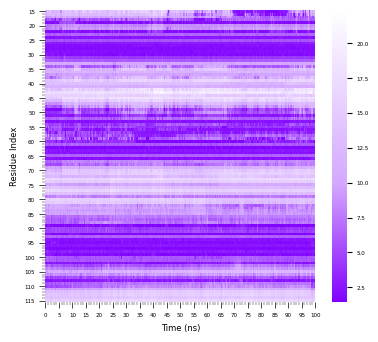

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

df = heatDat

# 创建自定义颜色映射
# 5以下颜色越小越深，大于等于5的白色
cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0, "#8000FF"), (0.4, "#D3A7FF"), (1, "#ffffff")],
    N=512
)

# 绘制热图
fig, ax = plt.subplots(figsize=(4, 3.5) )  # 设置图形大小
sns.heatmap(df, annot=False, cmap=cmap)#, norm=norm, fmt=".1f", cbar_kws=cbar_kws)  # 设置颜色条的标签

major_pos   = range(0, 1001, 50)
major_label = range(0, 101, 5)
minor_pos   = range(0, 1001, 10)

# major_pos   = range(0, 5001, 500)
# major_label = range(0, 501, 50)
# minor_pos   = range(0, 5001, 50)

plt.xticks(major_pos, major_label, rotation=0)
ax.xaxis.set_minor_locator(ticker.FixedLocator(minor_pos))
ax.tick_params(axis="x", which="major", direction="out", width=0.5, length=4, right=False,labelsize=4)
ax.tick_params(axis="x", which="minor", direction="out", width=0.3, length=2, right=False)

plt.yticks([x+0.5 for x in range(0, 101, 5)], range(15, 116, 5))
ax.tick_params(axis="y",reset=True, which="both", direction="out", width=0.5, length=4,labelsize=4,right=False)
ax.tick_params(axis="y", which="minor",reset=True, direction="out", width=0.3, length=2,zorder=1,right=False)

ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))


cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=4)  # 设置颜色条刻度的字体大小

plt.tight_layout(pad=1.5)

plt.ylabel("Residue Index", fontsize=6)
plt.xlabel("Time (ns)", fontsize=6)

plt.savefig("HeatMap_ssDNA_2.png", dpi=600)
plt.savefig("HeatMap_ssDNA_2.svg", dpi=600)
# plt.savefig("HeatMap_test.pdf", dpi=600)
# plt.savefig("HeatMap_test.svg", dpi=600)

plt.show()
